# Telco Customer Churn Prediction with XGBoost

## Project Overview

This notebook builds a machine learning model to predict customer churn using the Telco Customer Churn dataset. The goal is to identify customers who are likely to leave the company and understand the main factors that influence churn.

The project covers data cleaning, exploratory data analysis, feature preprocessing, XGBoost model training, model evaluation, feature importance, SHAP explainability, and business recommendations.

Customer churn prediction is useful for telecom companies because it helps detect high-risk customers early and design targeted retention strategies.

## Import Libraries

The required Python libraries are imported in this section. These libraries are used for data manipulation, visualization, preprocessing, model training, model evaluation, and explainability.

Main tools used in this notebook include pandas, NumPy, matplotlib, scikit-learn, XGBoost, and SHAP.

In [3]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,StratifiedKFold,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder,LabelBinarizer,OneHotEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score, roc_curve
import time



## Load Dataset

The Telco Customer Churn dataset is loaded into a pandas DataFrame. The dataset contains customer demographic information, account details, service subscriptions, contract type, payment method, charges, tenure, and churn status.

The target variable is `Churn`, which shows whether a customer left the company or stayed.

In [4]:
df=pd.read_csv(r"C:\Users\reyha\Desktop\DATA SCIENCE CLASS ITALY\data science class\telco customer churn\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## Exploratory Data Analysis

Exploratory Data Analysis is used to understand the structure of the dataset and identify important patterns before model training.

This section analyzes numerical features, class distribution, and customer behavior patterns. It helps reveal whether the dataset is imbalanced and which variables may be related to customer churn.

### Numeric Feature Distribution

Histograms are used to inspect the distribution of numerical features such as `SeniorCitizen` and `tenure`.

Understanding these distributions helps identify customer patterns and possible relationships between customer characteristics and churn behavior.

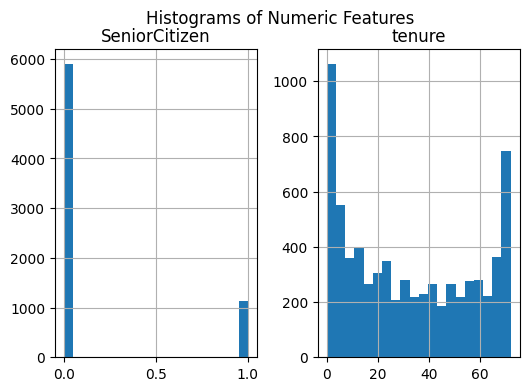

In [6]:
df.select_dtypes(include=["int64"]).hist(figsize=(6,4), bins=20)
plt.suptitle("Histograms of Numeric Features")
plt.show()

## Dataset Structure and Initial Checks

The dataset shape, column names, data types, and unique values are inspected to understand the available features.

This step is important before cleaning and preprocessing because it helps identify categorical variables, numerical variables, missing values, and possible data-quality issues.

In [7]:
df.shape

(7043, 21)

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
# Pip 21.3+ is required
!pip install -U xgboost


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\reyha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
df.nunique()

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

In [12]:
for col in df.columns:
    if df[col].nunique()==3 and df[col].dtype=="object":
        print(col,df[col].unique())
for col in df.columns:
     if df[col].nunique()==2 and (df[col].dtype=="object" or df[col].dtype=="int64"):
        print(col,df[col].unique())
                 

MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
gender ['Female' 'Male']
SeniorCitizen [0 1]
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
PaperlessBilling ['Yes' 'No']
Churn ['No' 'Yes']


In [13]:
df["PaymentMethod"].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

## Data Cleaning and Preprocessing

In this section, the dataset is cleaned and prepared for machine learning. Missing values are handled, categorical variables are encoded, and numerical features are prepared for model training.

The target variable is `Churn`, where `1` means the customer churned and `0` means the customer stayed.

Cleaning the data is important because machine learning models require consistent numeric and categorical inputs.

### Handling Missing and Invalid Values

Some values in the dataset may be blank, inconsistent, or stored as text instead of numeric values. In particular, `TotalCharges` must be converted into a numeric feature because it represents the total amount charged to the customer.

Invalid or missing values are handled before training the model to avoid errors and improve model reliability.

In [14]:
mask = (df["tenure"] == 0) & (df["TotalCharges"].str.strip() == "")

# نمایش ردیف‌ها
print(df.loc[mask, ["customerID", "tenure", "TotalCharges"]])
print("تعداد ردیف‌ها:", mask.sum())

      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             
3331  7644-OMVMY       0             
3826  3213-VVOLG       0             
4380  2520-SGTTA       0             
5218  2923-ARZLG       0             
6670  4075-WKNIU       0             
6754  2775-SEFEE       0             
تعداد ردیف‌ها: 11


In [15]:
df= df.replace(r'^\s*$', np.nan, regex=True)

In [16]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [17]:
if "tenure" in df.columns:  
    df.loc[df["tenure"] == 0, "TotalCharges"] = 0


In [18]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
print(df["TotalCharges"].dtype)

float64


In [19]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [20]:
# ستون SeniorCitizen
print("Min SeniorCitizen:", df["SeniorCitizen"].min())
print("Any negative in SeniorCitizen?:", (df["SeniorCitizen"] < 0).any())

# ستون tenure
print("Min tenure:", df["tenure"].min())
print("Any negative in tenure?:", (df["tenure"] < 0).any())


Min SeniorCitizen: 0
Any negative in SeniorCitizen?: False
Min tenure: 0
Any negative in tenure?: False


### Churn Class Distribution

The churn class distribution shows how many customers stayed and how many customers left the company.

This is important because churn datasets are often imbalanced. If most customers did not churn, accuracy alone can be misleading, so additional metrics such as recall, precision, F1-score, ROC-AUC, and Precision-Recall AUC are needed.

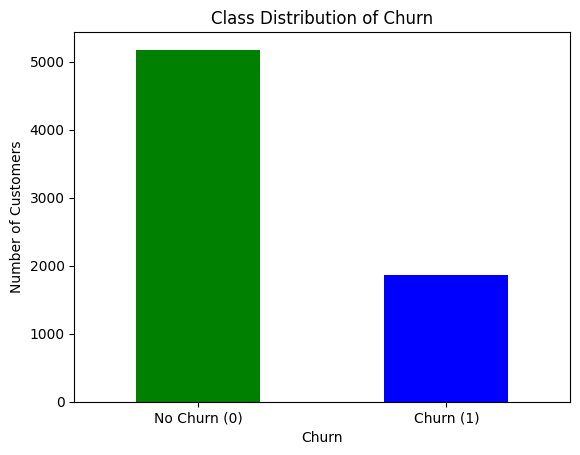

In [21]:
counts = df["Churn"].value_counts()
counts.plot(kind="bar", color=["green","blue"])
plt.xticks([0,1], ["No Churn (0)", "Churn (1)"], rotation=0)
plt.ylabel("Number of Customers")
plt.title("Class Distribution of Churn")
plt.show()

## Feature Preparation

The dataset is prepared for machine learning by transforming categorical variables into numeric format.

XGBoost requires numerical input, so binary categorical columns are encoded and multi-class categorical columns are converted using one-hot encoding. This allows the model to use customer information such as contract type, internet service, payment method, and support services.

In [22]:
binary_cols = [col for col in df.columns 
               if df[col].nunique() == 2 and df[col].dtype == "object"]

le = LabelBinarizer()

for col in binary_cols:
    df[col] = le.fit_transform(df[col])

In [23]:

cols_ohe = [c for c in df.columns if df[c].dtype == "object" and df[c].nunique() == 3]

if cols_ohe:

        ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")  
    

        enc_arr = ohe.fit_transform(df[cols_ohe])
        enc_df  = pd.DataFrame(enc_arr,
                           columns=ohe.get_feature_names_out(cols_ohe),
                           index=df.index)

    
        df = df.drop(columns=cols_ohe).join(enc_df)




In [24]:
pay_ene=OneHotEncoder(sparse_output=False, handle_unknown="ignore")
pay_arr = pay_ene.fit_transform(df[["PaymentMethod"]])
pay_df = pd.DataFrame(pay_arr,
                      columns=pay_ene.get_feature_names_out(["PaymentMethod"]),
                      index=df.index)

df = df.drop(columns="PaymentMethod").join(pay_df)

In [25]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,1,0,1,1,24,1,1,84.80,1990.50,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
7039,2234-XADUH,0,0,1,1,72,1,1,103.20,7362.90,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
7040,4801-JZAZL,0,0,1,1,11,0,1,29.60,346.45,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
7041,8361-LTMKD,1,1,1,0,4,1,1,74.40,306.60,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [26]:
df.shape

(7043, 42)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 42 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customerID                               7043 non-null   object 
 1   gender                                   7043 non-null   int64  
 2   SeniorCitizen                            7043 non-null   int64  
 3   Partner                                  7043 non-null   int64  
 4   Dependents                               7043 non-null   int64  
 5   tenure                                   7043 non-null   int64  
 6   PhoneService                             7043 non-null   int64  
 7   PaperlessBilling                         7043 non-null   int64  
 8   MonthlyCharges                           7043 non-null   float64
 9   TotalCharges                             7043 non-null   float64
 10  Churn                                    7043 no

### Input Features and Target Variable

The dataset is separated into input features `X` and the target variable `y`.

The target variable is `Churn`, where `1` represents churn customers and `0` represents non-churn customers. The `customerID` column is removed because it is only an identifier and does not provide useful predictive information.

In [28]:
#model
X=df.drop(columns=["customerID","Churn"])
y = df["Churn"]

## Train-Test Split

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate how well the model performs on unseen data.

Stratified splitting is used so that the churn and non-churn class proportions remain similar in both training and testing data.

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

## Model Training: XGBoost

XGBoost is trained as a supervised classification model to predict customer churn.

XGBoost is a gradient boosting algorithm that works well with structured tabular data. In this project, it learns patterns from customer information such as contract type, tenure, monthly charges, internet service, online security, tech support, and payment method.

A randomized hyperparameter search is used to test different model configurations and select a stronger model.

In [30]:
#xgboost model
param = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.1, 0.01, 0.001],
    "n_estimators": [50, 100, 200],
    "subsample": [0.8,1.0],
    "colsample_bytree": [0.8,1.0],
}


base_clf = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=42   
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rnd_model = RandomizedSearchCV(
    estimator=base_clf,
    param_distributions=param,
    n_iter=15,                 
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    refit=True,
    random_state=42,
    verbose=2
)
t0 = time.time()
rnd_model.fit(X, y)            
xgb_time = time.time() - t0


print(f"Training time: {xgb_time:.2f} seconds")
print("Best CV AUC:", rnd_model.best_score_)
print("Best params:", rnd_model.best_params_)


Fitting 5 folds for each of 15 candidates, totalling 75 fits
Training time: 42.82 seconds
Best CV AUC: 0.8480561071145303
Best params: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


### Hyperparameter Search Results

The cross-validation results are inspected to compare model configurations. The best configuration is selected based on validation performance.

This helps reduce the risk of choosing model parameters only by guesswork.

In [31]:
results = pd.DataFrame(rnd_model.cv_results_)
print(results[["params","mean_test_score","std_test_score","rank_test_score"]].head())


                                              params  mean_test_score  \
0  {'subsample': 1.0, 'n_estimators': 200, 'max_d...         0.843584   
1  {'subsample': 0.8, 'n_estimators': 200, 'max_d...         0.833263   
2  {'subsample': 0.8, 'n_estimators': 200, 'max_d...         0.842752   
3  {'subsample': 1.0, 'n_estimators': 200, 'max_d...         0.843482   
4  {'subsample': 0.8, 'n_estimators': 100, 'max_d...         0.839279   

   std_test_score  rank_test_score  
0        0.009410                3  
1        0.011248               14  
2        0.011316                5  
3        0.010524                4  
4        0.011442                9  


### Final Model Fitting

After the best XGBoost configuration is selected, the final model is trained on the training data.

This fitted model is then used for prediction and evaluation on the test set.

In [32]:
best_model = rnd_model.best_estimator_
best_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


## Model Evaluation

The model is evaluated using several metrics because customer churn is an imbalanced classification problem.

Accuracy alone is not enough because the model may perform well on the majority class while missing many churn customers.

The evaluation includes:

- Confusion matrix
- Precision
- Recall
- F1-score
- ROC-AUC
- Precision-Recall curve
- Average Precision score

Recall for the churn class is especially important because the business goal is to identify customers who are likely to leave.

### Confusion Matrix and Classification Report

The confusion matrix shows how many customers were correctly and incorrectly classified as churn or non-churn.

The classification report provides precision, recall, and F1-score for each class.

For churn prediction, recall for class `1` is important because it shows how many actual churn customers the model successfully detected.

In [33]:
# Make predictions on the test set
y_pred = best_model.predict(X_test)
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Confusion Matrix:\n{confusion}")
print(f"Classification Report:\n{report}")


Accuracy: 0.80
Confusion Matrix:
[[940  95]
 [188 186]]
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



### ROC Curve

The ROC curve shows the relationship between the true positive rate and false positive rate at different classification thresholds.

ROC-AUC measures how well the model separates churn customers from non-churn customers. A higher ROC-AUC means the model has stronger discrimination ability.

Test ROC-AUC: 0.8471440750213128


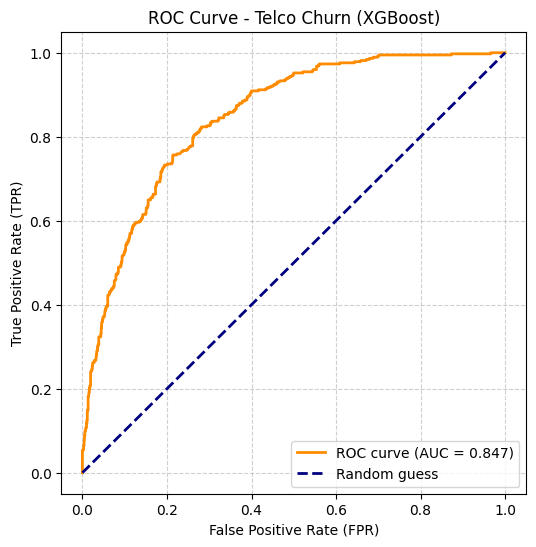

In [34]:
y_proba = best_model.predict_proba(X_test)[:, 1]  
auc = roc_auc_score(y_test, y_proba)
print("Test ROC-AUC:", auc)

fpr, tpr, thr = roc_curve(y_test, y_proba)


plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--", label="Random guess")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve - Telco Churn (XGBoost)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Precision-Recall Curve

The Precision-Recall curve is useful for imbalanced classification problems such as churn prediction.

Average Precision summarizes the trade-off between precision and recall. This metric is important because the churn class is smaller than the non-churn class.

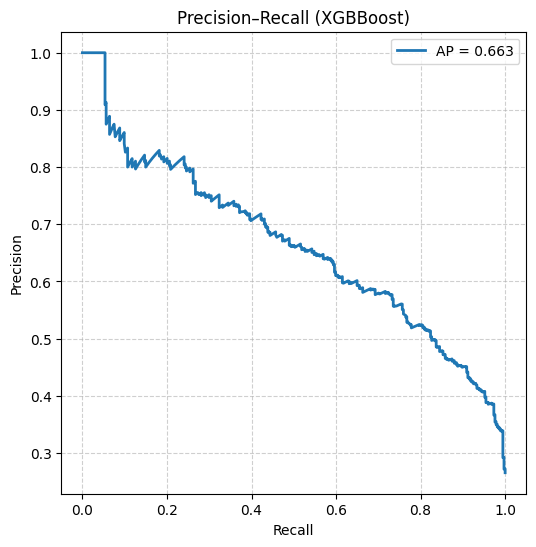

In [35]:
from sklearn.metrics import precision_recall_curve, average_precision_score
y_proba = best_model.predict_proba(X_test)[:,1]
ap = average_precision_score(y_test, y_proba)
p, r, th = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,6))
plt.plot(r, p, lw=2, label=f'AP = {ap:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision–Recall (XGBBoost)')
plt.legend(); plt.grid(True, ls='--', alpha=0.6); plt.show()


## Threshold Tuning

The default classification threshold is usually `0.5`, but this may not be the best choice for churn prediction.

In this section, the decision threshold is adjusted to improve the detection of churn customers. A lower threshold can increase recall for churn customers, although it may also increase false positives.

This trade-off is acceptable in many business cases because contacting some extra customers is usually less costly than missing customers who are likely to leave.

In [36]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report
# Youden's J: tpr - fpr را بیشینه کن
from sklearn.metrics import roc_curve
fpr, tpr, thr = roc_curve(y_test, y_proba)
j_scores = tpr - fpr
t_opt = thr[j_scores.argmax()]  

y_pred = (y_proba >= t_opt).astype(int)
cm = confusion_matrix(y_test, y_pred)
print("Optimal threshold:", float(t_opt))
print(cm)
print(classification_report(y_test, y_pred, digits=3))


Optimal threshold: 0.3181122839450836
[[813 222]
 [ 91 283]]
              precision    recall  f1-score   support

           0      0.899     0.786     0.839      1035
           1      0.560     0.757     0.644       374

    accuracy                          0.778      1409
   macro avg      0.730     0.771     0.741      1409
weighted avg      0.809     0.778     0.787      1409



## XGBoost Tree Visualization

Tree visualization is used to inspect how an individual XGBoost tree makes decisions.

This can help explain the model structure, but a single tree does not represent the whole XGBoost model because the final prediction is based on many boosted trees.

In [37]:
!pip install graphviz


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\reyha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


C:\Users\reyha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 5600x3200 with 0 Axes>

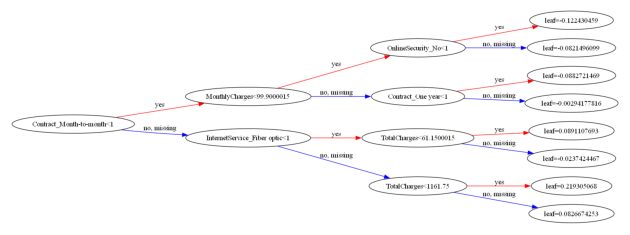

In [38]:
from xgboost import plot_tree



booster = best_model.get_booster()   

plt.figure(figsize=(28, 16), dpi=200)       
plot_tree(booster, num_trees=0, rankdir="LR")
plt.tight_layout()
plt.savefig("xgb_tree_0.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 5600x3200 with 0 Axes>

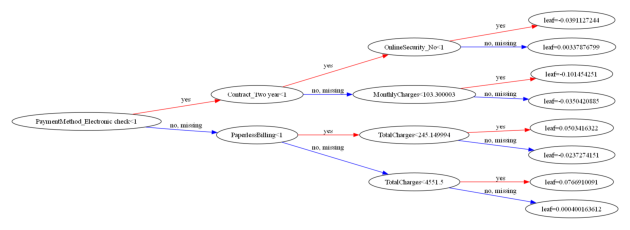

In [39]:
from xgboost import plot_tree



booster = best_model.get_booster()   

plt.figure(figsize=(28, 16), dpi=200)       
plot_tree(booster, num_trees=10, rankdir="LR")
plt.tight_layout()
plt.savefig("xgb_tree_0.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
from xgboost import to_graphviz

booster = best_model.get_booster()
g = to_graphviz(booster, num_trees=0, rankdir="LR")  

g.render("xgb_tree_0", format="svg")   



'xgb_tree_0.svg'

## Feature Importance

Feature importance is used to understand which variables contribute most to the XGBoost model predictions.

The most important features help explain the main drivers of churn. In this project, important churn-related features may include contract type, tenure, internet service, online security, tech support, monthly charges, total charges, and payment method.

This step connects the machine learning model to practical business interpretation.

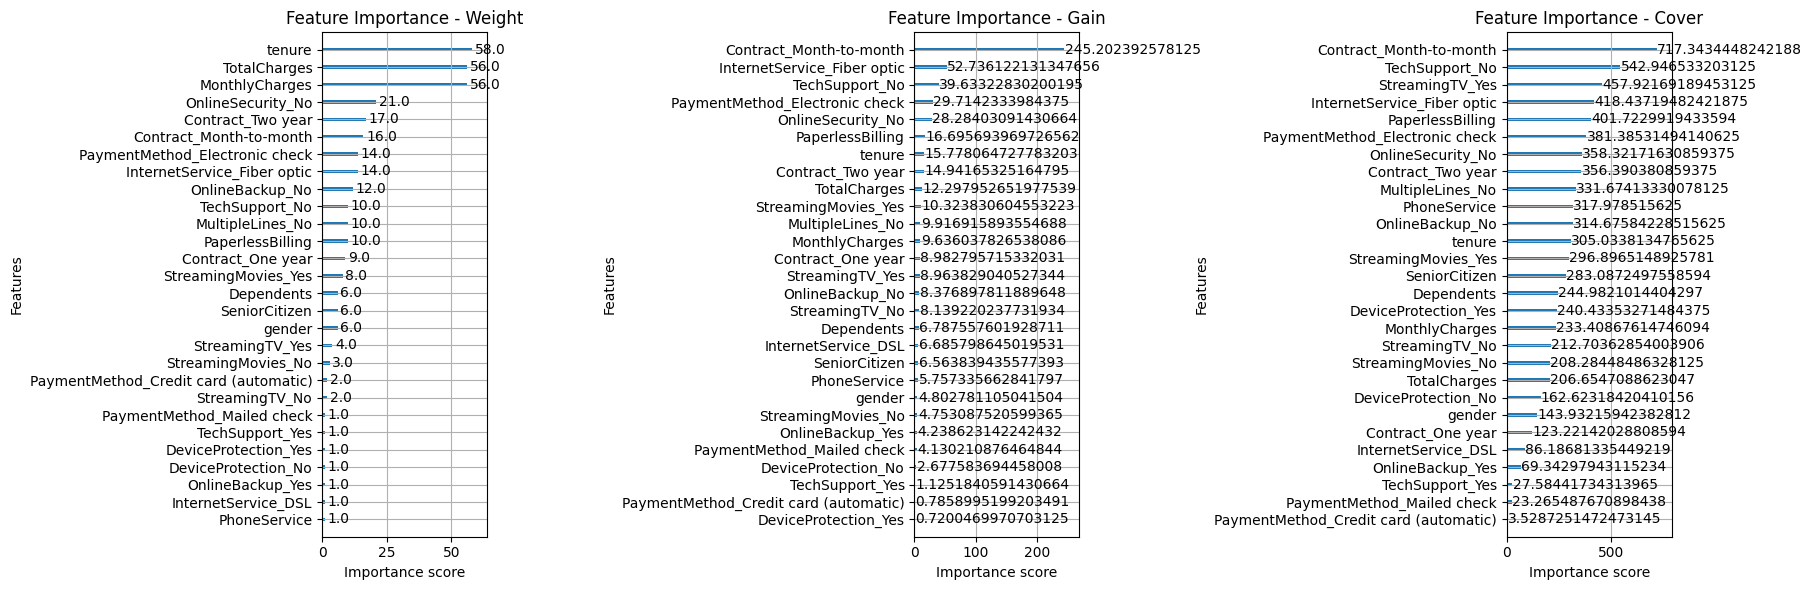

In [41]:
from xgboost import plot_importance


booster = best_model.get_booster()  

fig, axes = plt.subplots(1, 3, figsize=(18, 6))


plot_importance(booster, importance_type="weight", ax=axes[0])
axes[0].set_title("Feature Importance - Weight")


plot_importance(booster, importance_type="gain", ax=axes[1])
axes[1].set_title("Feature Importance - Gain")


plot_importance(booster, importance_type="cover", ax=axes[2])
axes[2].set_title("Feature Importance - Cover")

plt.tight_layout()
plt.show()


## SHAP Explainability

SHAP is used to explain how features influence the model predictions.

Positive SHAP values increase the predicted probability of churn, while negative SHAP values decrease the predicted probability of churn.

SHAP is useful because it explains not only which features are important, but also how those features affect churn risk.

In [42]:
!pip install shap



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: C:\Users\reyha\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


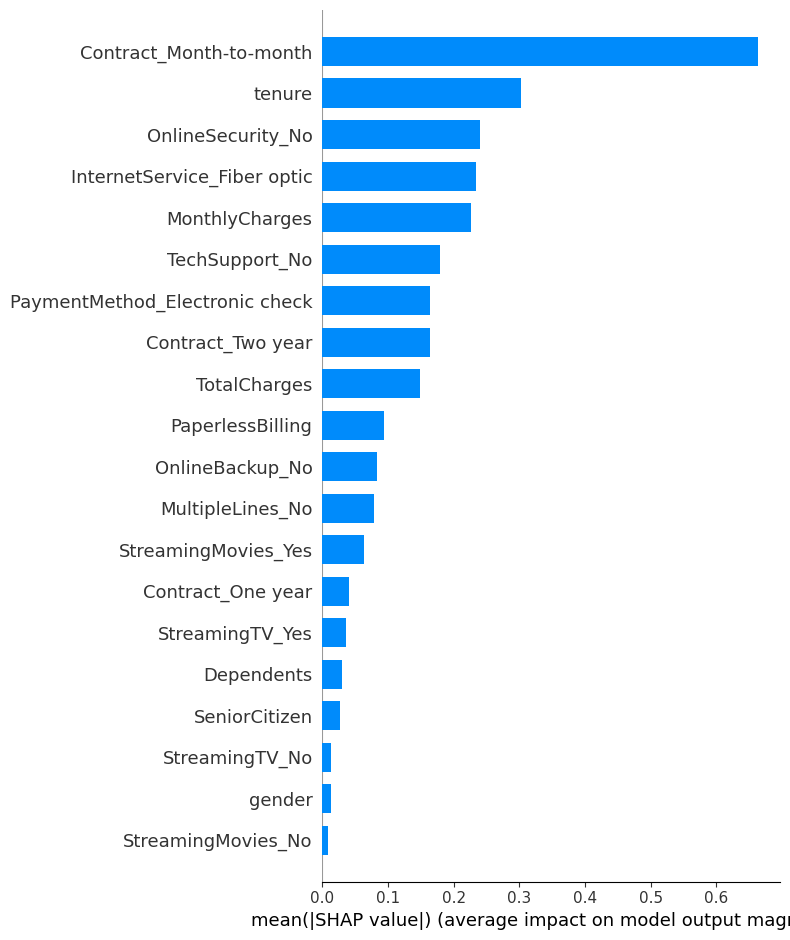

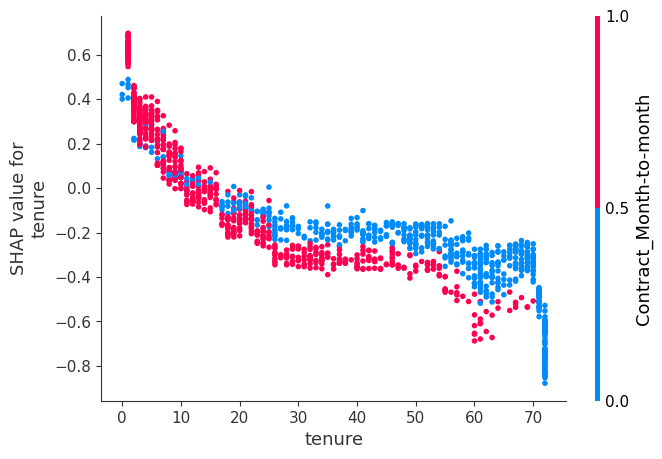

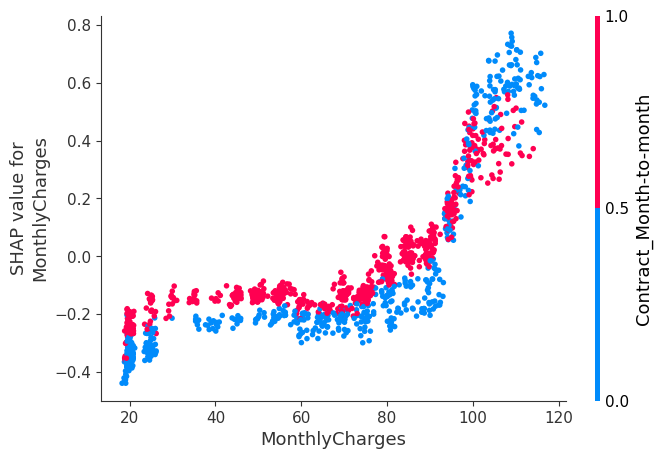

In [43]:

import shap


shap.initjs()


explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values, X_test, plot_type="bar")


i = 0
shap.force_plot(explainer.expected_value, shap_values[i, :], X_test.iloc[i, :])


shap.dependence_plot("tenure", shap_values, X_test)
shap.dependence_plot("MonthlyCharges", shap_values, X_test)


In [44]:
import os
os.makedirs("outputs", exist_ok=True)

In [45]:
predictions = pd.DataFrame({
    "customerID": df.loc[X_test.index, "customerID"],
    "actual_churn": y_test,
    "predicted_churn": y_pred,
    "churn_probability": y_proba
})

predictions.to_csv("outputs/xgboost_predictions.csv", index=False)

predictions.head()

,customerID,actual_churn,predicted_churn,churn_probability
437,4376-KFVRS,0,0,0.036690
2280,2754-SDJRD,0,1,0.754922
2235,9917-KWRBE,0,0,0.064736
4460,0365-GXEZS,0,1,0.324919
3761,9385-NXKDA,0,0,0.021159


In [47]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# For binary classification, sometimes SHAP returns a list
if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap.summary_plot(shap_values, X_test, show=False)

plt.tight_layout()
plt.savefig("outputs/xgboost_shap_summary.png", dpi=300, bbox_inches="tight")
plt.close()

## Business Insights

The model results suggest that churn is strongly related to contract type, tenure, monthly charges, internet service, online security, tech support, total charges, and payment method.

Key insights:

1. Customers with month-to-month contracts are more likely to churn.
2. Customers with low tenure are at higher risk, especially during the early customer lifecycle.
3. Higher monthly charges can increase churn risk.
4. Customers without online security or tech support may be more likely to leave.
5. Contract type is one of the strongest churn drivers.
6. Retention strategies should focus on customers with high predicted churn probability.

Possible business actions include offering contract upgrade incentives, targeted discounts, improved onboarding for new customers, better technical support, and personalized retention campaigns for high-risk customers.

## Conclusion

This notebook developed an XGBoost-based churn prediction model for the Telco Customer Churn dataset.

The model achieved useful predictive performance and provided interpretable insights through feature importance and SHAP analysis. The results show that churn is mainly influenced by contract type, tenure, monthly charges, internet service, online security, tech support, and payment method.

From a business perspective, the model can help identify high-risk customers early and support targeted retention strategies.